In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (mean_absolute_error,mean_squared_error)

In [2]:
model_df=pd.read_csv(r"C:\Users\ganesh\Desktop\All Projects\Predicative care load Forecasting\data\processed\hhs_feature.csv")

In [3]:
model_df["Date"]= pd.to_datetime(model_df["Date"])

In [4]:
model_df= model_df.sort_values("Date").reset_index(drop=True)

In [5]:
target="Children in HHS Care"

y=model_df[["Date",target]].copy()

In [6]:
y.head()

,Date,Children in HHS Care
0,2023-01-12,6566
1,2023-01-22,7122
2,2023-01-23,7280
3,2023-01-24,7433
4,2023-01-25,7538


In [7]:
y.tail()

,Date,Children in HHS Care
715,2025-12-15,2470
716,2025-12-16,2468
717,2025-12-17,2481
718,2025-12-18,2472
719,2025-12-21,2484


In [8]:
split_index=int(len(y) * 0.80)

train=y.iloc[:split_index].copy()
test=y.iloc[split_index:].copy()

print("Training observation:",len(train))
print("Testing observation:",len(test))

Training observation: 576
Testing observation: 144


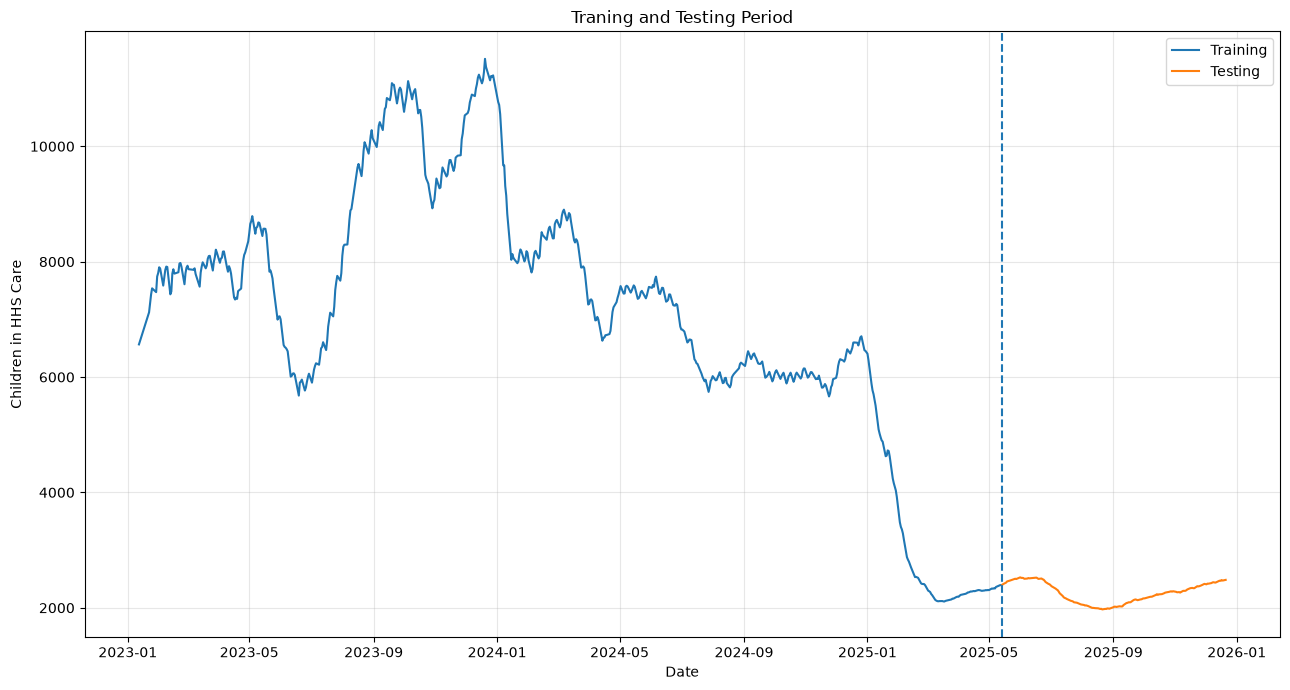

In [30]:
plt.figure(figsize=(13,7))

plt.plot(
    train["Date"],
    train[target],
    label="Training"
)

plt.plot(
    test["Date"],
    test[target],
    label="Testing"
)

plt.axvline(
    test["Date"].iloc[0],
    linestyle="--"
)

plt.title("Traning and Testing Period")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.3)
plt.show()



# 1.BASELINE MODELS

# 1) NAIVE FORECAST

In [10]:
naive_predication=np.repeat(
    train[target].iloc[-1],
    len(test)
)

In [11]:
naive_mae=mean_absolute_error(
    test[target],
    naive_predication
)

print("Naive MAE:",naive_mae)

Naive MAE: 186.50694444444446


In [12]:
naive_rmse=np.sqrt(
    mean_squared_error(
        test[target],
        naive_predication
    )
)

print("Naive RMSE:",naive_rmse)

Naive RMSE: 227.22854684216065


# 2) MOVING AVERAGE 

In [13]:
window=7
moving_average_predication=np.repeat(
    train[target].tail(window).mean(),
    len(test)
)

In [14]:
ma_mae=mean_absolute_error(
    test[target],
    moving_average_predication
)

ma_rmse=np.sqrt(
    mean_squared_error(
        test[target],
        moving_average_predication
    )
)

print("Moving Average MAE:",ma_mae)
print("Moving Average RMSE:",ma_rmse)

Moving Average MAE: 174.73313492063497
Moving Average RMSE: 208.66256400685262


In [15]:
baseline_results=pd.DataFrame({
    "Model":[
        "Naive","7-Day Moving Average"
    ],
    "MAE":[
        naive_mae,ma_mae
    ],
    "RMSE":[
        naive_rmse,ma_rmse
    ]
})

baseline_results

,Model,MAE,RMSE
0,Naive,186.506944,227.228547
1,7-Day Moving Average,174.733135,208.662564


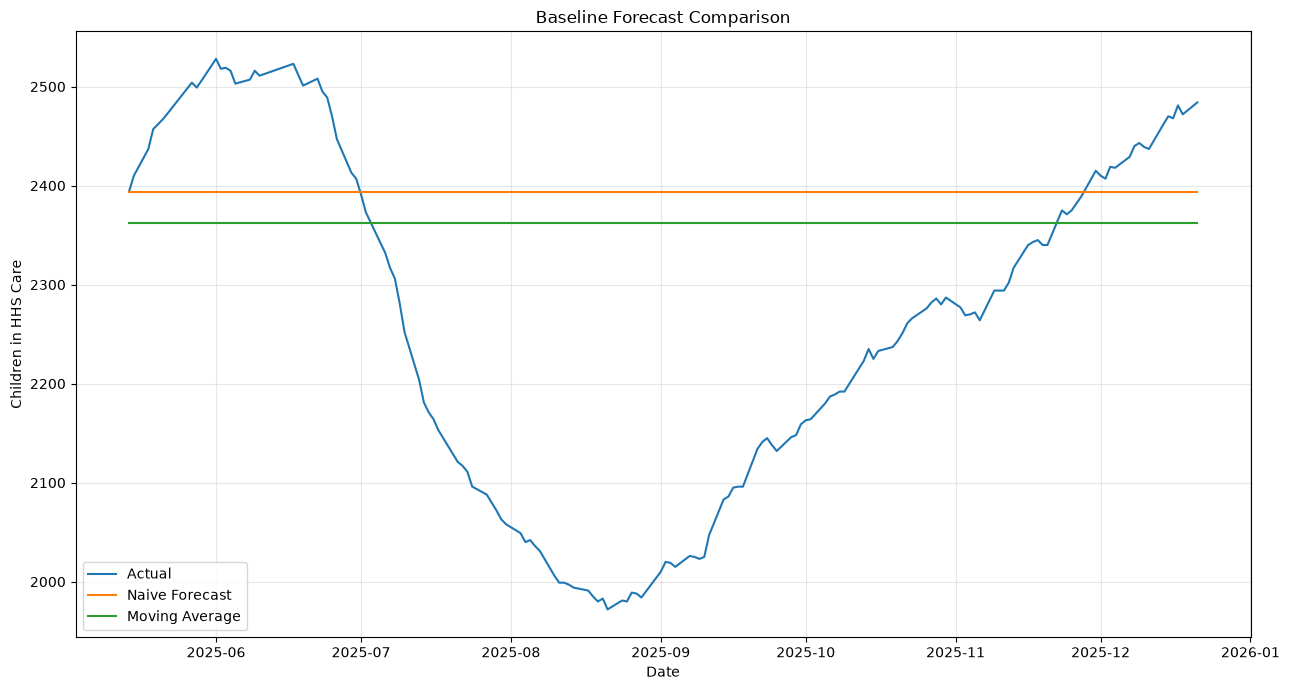

In [16]:
plt.figure(figsize=(13,7))

plt.plot(
    test["Date"],
    test[target],
    label="Actual"
)

plt.plot(
    test["Date"],
    naive_predication,
    label="Naive Forecast"
)

plt.plot(
    test["Date"],
    moving_average_predication,
    label="Moving Average"
)

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. EXPONENTIAL SMOOTHING

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [18]:
train_values=train[target].values

exp_model=ExponentialSmoothing(
    train_values,
    trend="add",
    seasonal=None
)

exp_fit=exp_model.fit(
    optimized=True
)

In [19]:
exp_predication=exp_fit.forecast(
    len(test)
)

In [20]:
exp_mae=mean_absolute_error(
    test[target],
    exp_predication
)

exp_rmse=np.sqrt(
    mean_squared_error(
        test[target],
        exp_predication
    )
)

print("Exponential Smoothng MAE:",exp_mae)
print("Exponential Smoothing RMSE:",exp_rmse)

Exponential Smoothng MAE: 703.5138031953934
Exponential Smoothing RMSE: 786.7896260372617


In [21]:
results=pd.DataFrame({
    "model":[
        "Naive",
        "7-Day Moving Average",
        "Exponential Smoothing"
    ],
    "MAE":[
        naive_mae,ma_mae,exp_mae
    ],
    "RMSE":[
        naive_rmse,ma_rmse,exp_rmse
    ]
})

results

,model,MAE,RMSE
0,Naive,186.506944,227.228547
1,7-Day Moving Average,174.733135,208.662564
2,Exponential Smoothing,703.513803,786.789626


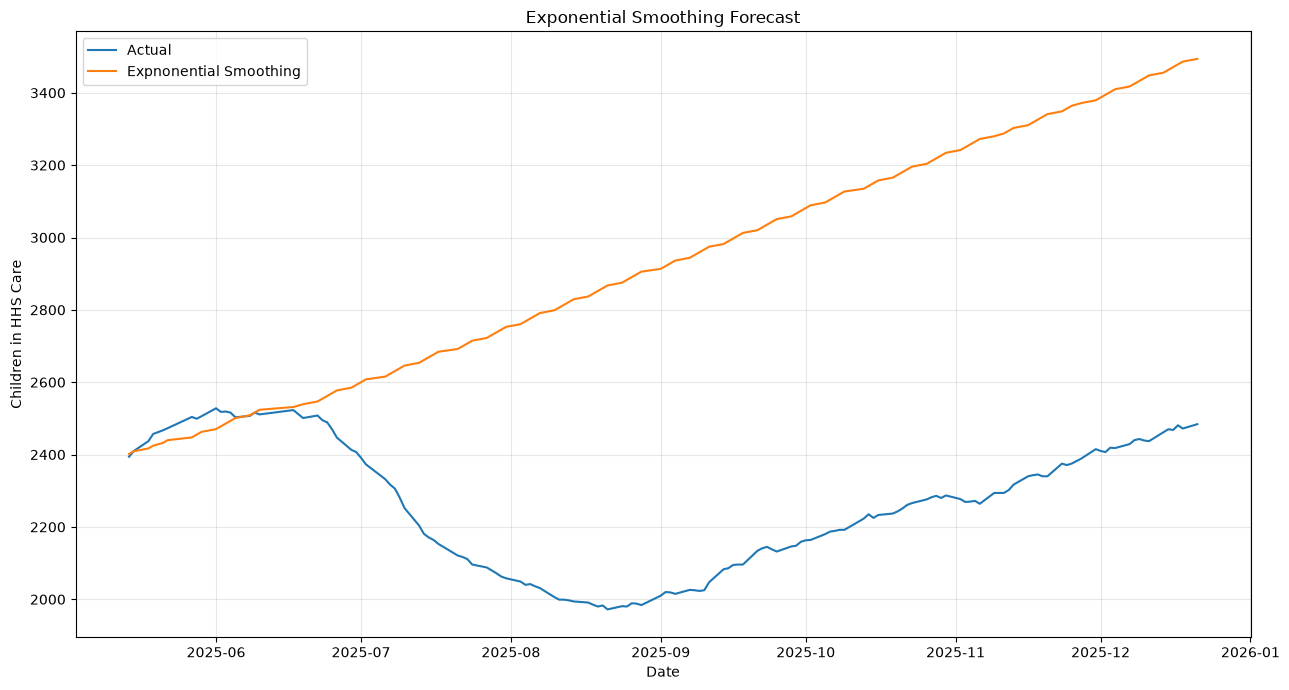

In [22]:
plt.figure(figsize=(13,7))

plt.plot(
    test["Date"],
    test[target],
    label="Actual"
)

plt.plot(
    test["Date"],
    exp_predication,
    label="Expnonential Smoothing"
)

plt.title("Exponential Smoothing Forecast")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exponential Smoothing Result

Exponential Smoothing produced an MAE of approximately 703.51 and an RMSE of approximately 786.79, substantially worse than both the Naïve and 7-day Moving Average baselines.

The poor performance may be related to the irregular reporting frequency of the source dataset. The data contains systematic missing calendar dates, particularly Fridays and Saturdays. Therefore, standard regular-frequency exponential smoothing is not considered an appropriate final forecasting model for this dataset.

The model is retained as a benchmark but excluded from final model selection.

# 3. ARIMA

In [23]:
from statsmodels.tsa.arima.model import ARIMA

In [25]:
arima_model=ARIMA(
    train[target],
    order=(1,1,1)
)

arima_fit=arima_model.fit()

In [26]:
arima_predication=arima_fit.forecast(
    steps=len(test)
)

In [27]:
arima_mae=mean_absolute_error(
    test[target],
    arima_predication
)

arima_rmse=np.sqrt(
    mean_squared_error(
        test[target],
        arima_predication
    )
)

print("ARIMA MAE:",arima_mae)
print("ARIMA RMSE:",arima_rmse)

ARIMA MAE: 186.63942655311791
ARIMA RMSE: 227.42381125793565


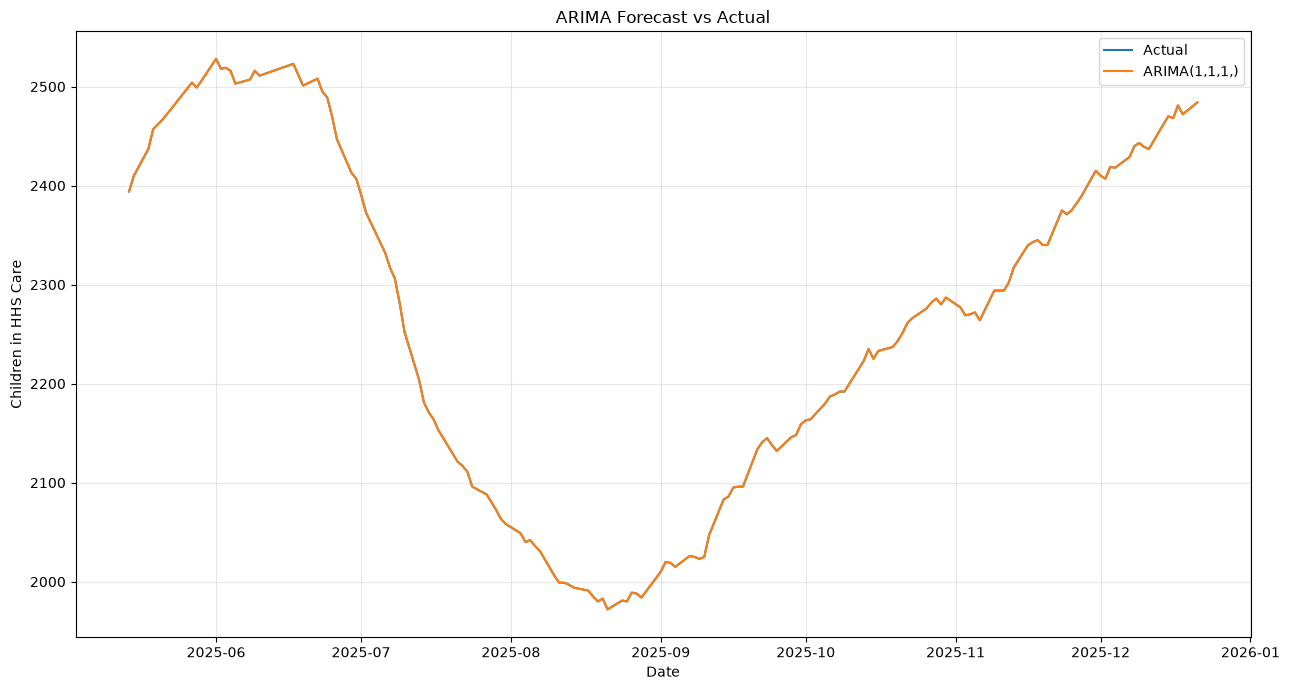

In [28]:
plt.figure(figsize=(13,7))

plt.plot(
    test["Date"],
    test[target],
    label="Actual"
)

plt.plot(
    test["Date"],
    test[target],
    label="ARIMA(1,1,1,)"
)

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
results=pd.DataFrame({
    "Model":[
        "Naive",
        "7-Day Moving Average",
        "Exponential Smoothing",
        "ARIMA(1,1,1)"
    ],
    "MAE":[
        naive_mae,
        ma_mae,
        exp_mae,
        arima_mae
    ],
    "RMSE":[
        naive_rmse,
        ma_rmse,
        exp_rmse,
        arima_rmse
    ]
})

results.sort_values("MAE")

,Model,MAE,RMSE
1,7-Day Moving Average,174.733135,208.662564
0,Naive,186.506944,227.228547
3,"ARIMA(1,1,1)",186.639427,227.423811
2,Exponential Smoothing,703.513803,786.789626


# 4. MACHINE LEARNING MODELS
## 4.1 RANDOM FOREST REGRESSOR

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [34]:
features= [
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "week_of_year",
    "is_weekend",
    "Net_Pressure",
    "Discharge_to_Transfer_Ratio",
    "hhs_lag_1",
    "hhs_lag_7",
    "hhs_lag_14",
    "hhs_lag_28",
    "transfer_lag_1",
    "transfer_lag_7",
    "transfer_lag_14",
    "discharge_lag_1",
    "discharge_lag_7",
    "discharge_lag_14",
    "hhs_rolling_mean_7d",
    "hhs_rolling_mean_14d",
    "hhs_rolling_std_7d",
    "hhs_rolling_std_14d"
]

In [35]:
ml_df=model_df[
    ["Date",target] + features
].dropna().copy()

In [36]:
print(ml_df.shape)

(490, 25)


In [39]:
print(ml_df.isna().sum().sum())

0


In [40]:
ml_split= int(len(ml_df)* 0.80)

ml_train=ml_df.iloc[:ml_split].copy()
ml_test=ml_df.iloc[ml_split:].copy()

print("ML training onservations:", len(ml_train))
print("ML testing observations:",len(ml_test))

ML training onservations: 392
ML testing observations: 98


In [42]:
x_train=ml_train[features]
y_train=ml_train[target]

x_test=ml_test[features]
y_test=ml_test[target]


In [43]:
rf_model=RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [45]:
rf_model.fit(
    x_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [47]:
rf_predication=rf_model.predict(x_test)